# 02 — Preprocessing & Stratified Split

**Fase 1** — Loader pipeline + duplikat fisik split 5-seed

**Referensi:** Proposal BAB 3.3.4, 3.3.5, Tabel 3.3

---

**Langkah-langkah:**
1. Konfigurasi & import
2. Buat 5 seed split (train_test_split dua tahap, stratified)
3. Salin + convert RGB ke dataset/split/seed{n}/{train,val,test}/{kelas}/
4. Sanity check: jumlah, proporsi, disjoint
5. Tulis src/data_pipeline.py
6. Validasi: demo augmentasi (TF) + grid train vs val
7. Summary & Definition of Done

## Langkah 1 — Konfigurasi & Import

In [11]:
import os, shutil
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Konfigurasi
REPO_ROOT     = Path("/media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR")
PROCESSED_DIR = REPO_ROOT / "dataset" / "processed"
SPLIT_ROOT    = REPO_ROOT / "dataset" / "split"
RESULTS_FIGS  = REPO_ROOT / "results" / "figures" / "phase 1"
RESULTS_FIGS.mkdir(parents=True, exist_ok=True)

KLAS_FINAL = ['Cerah', 'Mendung', 'Hujan', 'Berawan', 'Berkabut']
SEEDS      = [42, 123, 2024, 7, 99]
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
ROTATION_DEG   = 20
SHIFT_FRACTION = 0.15
ZOOM_FRACTION  = 0.15
TARGET_PER_CLASS = 170

print("Repo root  :", REPO_ROOT)
print("Seeds      :", SEEDS)
print("Rasio      : train=0.70 val=0.15 test=0.15")

Repo root  : /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR
Seeds      : [42, 123, 2024, 7, 99]
Rasio      : train=0.70 val=0.15 test=0.15


## Langkah 2 — Buat Split dengan `train_test_split` Dua Tahap

In [12]:
# Baca manifest dari Fase 0
manifest = pd.read_csv(PROCESSED_DIR / "manifest.csv")
print("Manifest:", len(manifest), "baris")

# Acak manifest (seed tetap, reproducibility)
np.random.seed(42)
manifest = manifest.sample(frac=1, random_state=42).reset_index(drop=True)

# Struktur: { seed: { "train": [...], "val": [...], "test": [...] } }
split_manifests = {}

for seed in SEEDS:
    seed_splits = {"train": [], "val": [], "test": []}
    for kelas in KLAS_FINAL:
        kelas_files = manifest[manifest["kelas"] == kelas]["filename_baru"].tolist()

        # -- Tahap 1: train (70%) vs rest (30%) --
        train_files, rest_files = train_test_split(
            kelas_files,
            test_size=(VAL_RATIO + TEST_RATIO),
            random_state=seed,
        )

        # -- Tahap 2: rest -> val (50%) vs test (50%) --
        val_files, test_files = train_test_split(
            rest_files,
            test_size=0.5,
            random_state=seed,
        )

        seed_splits["train"].extend(train_files)
        seed_splits["val"].extend(val_files)
        seed_splits["test"].extend(test_files)

    total = len(seed_splits["train"]) + len(seed_splits["val"]) + len(seed_splits["test"])
    assert total == len(KLAS_FINAL) * TARGET_PER_CLASS, \
        "Seed " + str(seed) + ": total=" + str(total) + \
        ", expected " + str(len(KLAS_FINAL) * TARGET_PER_CLASS)

    split_manifests[seed] = seed_splits
    print("Seed", seed, ": train =", len(seed_splits["train"]),
          ", val =", len(seed_splits["val"]),
          ", test =", len(seed_splits["test"]),
          ", total =", total, "| OK")

print("\n5 seed split siap.")

Manifest: 850 baris
Seed 42 : train = 595 , val = 125 , test = 130 , total = 850 | OK
Seed 123 : train = 595 , val = 125 , test = 130 , total = 850 | OK
Seed 2024 : train = 595 , val = 125 , test = 130 , total = 850 | OK
Seed 7 : train = 595 , val = 125 , test = 130 , total = 850 | OK
Seed 99 : train = 595 , val = 125 , test = 130 , total = 850 | OK

5 seed split siap.


## Langkah 3 — Salin File + Konversi RGB ke `dataset/split/`

In [13]:
print("=== Menyalin file + convert RGB ===\n")

total_copied = 0
for seed in SEEDS:
    print("Seed:", seed)
    for subset, filenames in split_manifests[seed].items():
        # Bangun dict: filename -> kelas (dari manifest)
        fname_to_kelas = dict(
            zip(manifest["filename_baru"], manifest["kelas"])
        )

        for fname in filenames:
            kelas = fname_to_kelas.get(fname)
            if kelas is None:
                # Fallback: ekstrak kelas dari prefix filename
                kelas = next((k for k in KLAS_FINAL if fname.startswith(k)), None)
            if kelas is None:
                raise ValueError("Tidak bisa tentukan kelas untuk: " + fname)

            # Source: dataset/processed/{kelas}/{fname}
            src_path = PROCESSED_DIR / kelas / fname
            if not src_path.exists():
                raise FileNotFoundError("Tidak ditemukan: " + str(src_path))

            # Destination: dataset/split/seed{n}/{subset}/{kelas}/{fname}
            dest_dir = SPLIT_ROOT / ("seed" + str(seed)) / subset / kelas
            dest_dir.mkdir(parents=True, exist_ok=True)
            dest_path = dest_dir / fname

            with Image.open(src_path) as img:
                if img.mode != "RGB":
                    img = img.convert("RGB")
                img.save(dest_path, format="JPEG", quality=95)

            total_copied += 1

        # Summary per subset
        subset_dir = SPLIT_ROOT / ("seed" + str(seed)) / subset
        copied_here = sum(
            len(list((subset_dir / k).glob("*.jpg"))) +
            len(list((subset_dir / k).glob("*.jpeg"))) +
            len(list((subset_dir / k).glob("*.png")))
            for k in KLAS_FINAL
        )
        print(" ", subset, ":", copied_here, "cintra OK")

expected_total = len(SEEDS) * len(KLAS_FINAL) * TARGET_PER_CLASS
print("\nTotal disalin :", total_copied)
print("Expected       :", expected_total)
assert total_copied == expected_total, "Jumlah tidak cocok!"
print("OK -- semua file ke dataset/split/seed{n}/{subset}/{kelas}/ dan dikonversi RGB")

=== Menyalin file + convert RGB ===

Seed: 42
  train : 595 cintra OK
  val : 125 cintra OK
  test : 130 cintra OK
Seed: 123
  train : 595 cintra OK
  val : 125 cintra OK
  test : 130 cintra OK
Seed: 2024
  train : 595 cintra OK
  val : 125 cintra OK
  test : 130 cintra OK
Seed: 7
  train : 595 cintra OK
  val : 125 cintra OK
  test : 130 cintra OK
Seed: 99
  train : 595 cintra OK
  val : 125 cintra OK
  test : 130 cintra OK

Total disalin : 4250
Expected       : 4250
OK -- semua file ke dataset/split/seed{n}/{subset}/{kelas}/ dan dikonversi RGB


## Langkah 4 — Sanity Check

In [14]:
print("=" * 60)
print("SANITY CHECK -- PER SEED")
print("=" * 60)

# Formula yang match persis dengan train_test_split sklearn:
#   train = round(170 * 0.70) = 119  per kelas
#   val   = int(170 * 0.15)   = 25   per kelas  (train_test_split pakai int() untuk val)
#   test  = 170 - 119 - 25     = 26   per kelas
# Alasan int() bukan round() untuk val: round(25.5)=26 (banker's rounding),
# tapi train_test_split aktual menghasilkan 25.

def count_files(folder):
    return (len(list(folder.glob("*.jpg"))) +
            len(list(folder.glob("*.jpeg"))) +
            len(list(folder.glob("*.png"))))

all_ok = True
for seed in SEEDS:
    print()
    print("Seed:", seed)

    subset_counts = {}
    for subset in ("train", "val", "test"):
        subset_dir = SPLIT_ROOT / ("seed" + str(seed)) / subset
        total_files = 0
        for kelas in KLAS_FINAL:
            total_files += count_files(subset_dir / kelas)
        subset_counts[subset] = total_files

    train_n = subset_counts["train"]
    val_n   = subset_counts["val"]
    test_n  = subset_counts["test"]

    # round() untuk train (kompensasi floating-point: 170*0.70=118.9999...)
    # int() untuk val (train_test_split pakai int() untuk val dari sisa)
    expected_train_per_class = round(TARGET_PER_CLASS * TRAIN_RATIO)
    expected_val_per_class   = int(TARGET_PER_CLASS * VAL_RATIO)
    expected_train = len(KLAS_FINAL) * expected_train_per_class
    expected_val   = len(KLAS_FINAL) * expected_val_per_class
    expected_test  = len(KLAS_FINAL) * TARGET_PER_CLASS - expected_train - expected_val

    ok_t = train_n == expected_train
    ok_v = val_n   == expected_val
    ok_e = test_n  == expected_test

    print("  train:", train_n, "(target", expected_train, ")", "OK" if ok_t else "GAGAL")
    print("  val  :", val_n, "(target", expected_val, ")", "OK" if ok_v else "GAGAL")
    print("  test :", test_n, "(target", expected_test, ")", "OK" if ok_e else "GAGAL")

    if not (ok_t and ok_v and ok_e):
        print("  ---> MASALAH: jumlah tidak sesuai target!")
        all_ok = False

    # Breakdown per kelas
    print("  Breakdown per kelas:")
    for subset in ("train", "val", "test"):
        subset_dir = SPLIT_ROOT / ("seed" + str(seed)) / subset
        for kelas in KLAS_FINAL:
            n = count_files(subset_dir / kelas)
            print("    ", subset, kelas + ":", n)

    # Disjoint check
    train_set = set(split_manifests[seed]["train"])
    val_set   = set(split_manifests[seed]["val"])
    test_set  = set(split_manifests[seed]["test"])
    overlap   = train_set & val_set | train_set & test_set | val_set & test_set
    ok_disjoint = len(overlap) == 0
    print("  Disjoint:", "OK -- tidak ada overlap" if ok_disjoint
                  else "OVERLAP! File:" + str(sorted(overlap)[:5]))
    if not ok_disjoint:
        all_ok = False

print()
if all_ok:
    print("SEMUA SANITY CHECK MEMENUHI SYARAT")
else:
    print("ADA MASALAH -- perbaiki sebelum lanjut Fase 2")


SANITY CHECK -- PER SEED

Seed: 42
  train: 595 (target 595 ) OK
  val  : 125 (target 125 ) OK
  test : 130 (target 130 ) OK
  Breakdown per kelas:
     train Cerah: 119
     train Mendung: 119
     train Hujan: 119
     train Berawan: 119
     train Berkabut: 119
     val Cerah: 25
     val Mendung: 25
     val Hujan: 25
     val Berawan: 25
     val Berkabut: 25
     test Cerah: 26
     test Mendung: 26
     test Hujan: 26
     test Berawan: 26
     test Berkabut: 26
  Disjoint: OK -- tidak ada overlap

Seed: 123
  train: 595 (target 595 ) OK
  val  : 125 (target 125 ) OK
  test : 130 (target 130 ) OK
  Breakdown per kelas:
     train Cerah: 119
     train Mendung: 119
     train Hujan: 119
     train Berawan: 119
     train Berkabut: 119
     val Cerah: 25
     val Mendung: 25
     val Hujan: 25
     val Berawan: 25
     val Berkabut: 25
     test Cerah: 26
     test Mendung: 26
     test Hujan: 26
     test Berawan: 26
     test Berkabut: 26
  Disjoint: OK -- tidak ada overlap

See

## Langkah 5 — Tulis `src/data_pipeline.py`

In [15]:
SRC_FILE = REPO_ROOT / "src" / "data_pipeline.py"

if SRC_FILE.exists():
    print("src/data_pipeline.py sudah ada -- skip. Lokasi:", SRC_FILE)
else:
    pipeline_code = (
        '"""\n'
        'data_pipeline.py -- Fase 1\n'
        'Fungsi loader tf.data untuk EfficientNetB0 dan ResNet50.\n'
        'Dipanggil oleh kedua notebook training (Fase 2).\n'
        '"""\n'
        'import os\n'
        'from pathlib import Path\n'
        'import tensorflow as tf\n\n'
        'IMG_SIZE = (224, 224)\n'
        'BATCH_SIZE_DEFAULT = 32\n'
        'SEEDS = [42, 123, 2024, 7, 99]\n'
        'TRAIN_RATIO = 0.70\n'
        'VAL_RATIO   = 0.15\n'
        'TEST_RATIO  = 0.15\n'
        'ROTATION_DEG   = 20\n'
        'SHIFT_FRACTION = 0.15\n'
        'ZOOM_FRACTION  = 0.15\n'
        "CLASS_NAMES = ['Berkabut', 'Berawan', 'Cerah', 'Hujan', 'Mendung']\n\n"
        'def _get_augment_layers():\n'
        '    return tf.keras.Sequential([\n'
        '        tf.keras.layers.RandomRotation(factor=ROTATION_DEG / 360.0,\n'
        '                                      fill_mode="reflect", seed=None),\n'
        '        tf.keras.layers.RandomTranslation(\n'
        '            height_factor=(-SHIFT_FRACTION, SHIFT_FRACTION),\n'
        '            width_factor =(-SHIFT_FRACTION, SHIFT_FRACTION),\n'
        '            fill_mode="reflect", seed=None),\n'
        '        tf.keras.layers.RandomZoom(\n'
        '            height_factor=(-ZOOM_FRACTION, ZOOM_FRACTION),\n'
        '            width_factor =(-ZOOM_FRACTION, ZOOM_FRACTION), seed=None),\n'
        '        tf.keras.layers.RandomFlip(mode="horizontal", seed=None),\n'
        '    ])\n\n'
        'def build_tf_dataset(seed, subset, preprocess_fn,\n'
        '                    augment=False, batch_size=BATCH_SIZE_DEFAULT):\n'
        '    if subset not in ("train", "val", "test"):\n'
        '        raise ValueError("subset harus train|val|test")\n'
        '    split_root = Path(__file__).parent.parent / "dataset" / "split" / f"seed{seed}" / subset\n'
        '    ds = tf.keras.preprocessing.image_dataset_from_directory(\n'
        '        directory=str(split_root),\n'
        '        labels="inferred", label_mode="int",\n'
        '        class_names=CLASS_NAMES,\n'
        '        image_size=IMG_SIZE,\n'
        '        batch_size=batch_size,\n'
        '        shuffle=(subset == "train"),\n'
        '        seed=seed,\n'
        '    )\n'
        '    if augment and subset == "train":\n'
        '        aug_layers = _get_augment_layers()\n'
        '        ds = ds.map(lambda x, y: (aug_layers(x, training=True), y),\n'
        '                    num_parallel_calls=tf.data.AUTOTUNE)\n'
        '    ds = ds.map(lambda x, y: (preprocess_fn(x), y),\n'
        '                num_parallel_calls=tf.data.AUTOTUNE)\n'
        '    return ds.prefetch(tf.data.AUTOTUNE)\n\n'
        'def get_split_info(seed):\n'
        '    split_root = Path(__file__).parent.parent / "dataset" / "split" / f"seed{seed}"\n'
        '    info = {}\n'
        '    for subset in ["train", "val", "test"]:\n'
        '        count = sum(\n'
        '            len(list((split_root/subset/k).glob("*.jpg"))) +\n'
        '            len(list((split_root/subset/k).glob("*.jpeg"))) +\n'
        '            len(list((split_root/subset/k).glob("*.png")))\n'
        '            for k in CLASS_NAMES)\n'
        '        info[subset] = count\n'
        '    return info\n'
    )
    SRC_FILE.parent.mkdir(parents=True, exist_ok=True)
    SRC_FILE.write_text(pipeline_code)
    print("src/data_pipeline.py ditulis --", SRC_FILE)

src/data_pipeline.py sudah ada -- skip. Lokasi: /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR/src/data_pipeline.py


## Langkah 6 — Validasi Augmentasi dengan TensorFlow

In [16]:
import tensorflow as tf
import sys
sys.path.insert(0, str(REPO_ROOT / "src"))

from data_pipeline import build_tf_dataset, CLASS_NAMES

print("TensorFlow :", tf.__version__)
print("GPU        :", bool(tf.config.list_physical_devices('GPU')))
print("Classes    :", CLASS_NAMES)

preprocess_eff = tf.keras.applications.efficientnet.preprocess_input

# Dataset train (augmented) dan val (non-augmented) -- seed 42
ds_train_demo = build_tf_dataset(42, "train", preprocess_eff, augment=True,  batch_size=6)
ds_val_demo   = build_tf_dataset(42, "val",   preprocess_eff, augment=False, batch_size=6)

batch_train = next(iter(ds_train_demo))
batch_val   = next(iter(ds_val_demo))
imgs_train, labels_train = batch_train
imgs_val,   labels_val   = batch_val

print()
print("Batch train shape:", imgs_train.shape, "| labels:", labels_train.shape)
print("Batch val shape  :", imgs_val.shape,   "| labels:", labels_val.shape)
print("OK -- tf.data pipeline berjalan, augmentasi aktif di train, nonaktif di val")

TensorFlow : 2.21.0
GPU        : False
Classes    : ['Berkabut', 'Berawan', 'Cerah', 'Hujan', 'Mendung']
Found 595 files belonging to 5 classes.
Found 125 files belonging to 5 classes.

Batch train shape: (6, 224, 224, 3) | labels: (6,)
Batch val shape  : (6, 224, 224, 3) | labels: (6,)
OK -- tf.data pipeline berjalan, augmentasi aktif di train, nonaktif di val


## Langkah 6b — Grid Visualisasi: Train (Augmented) vs Val (Original)

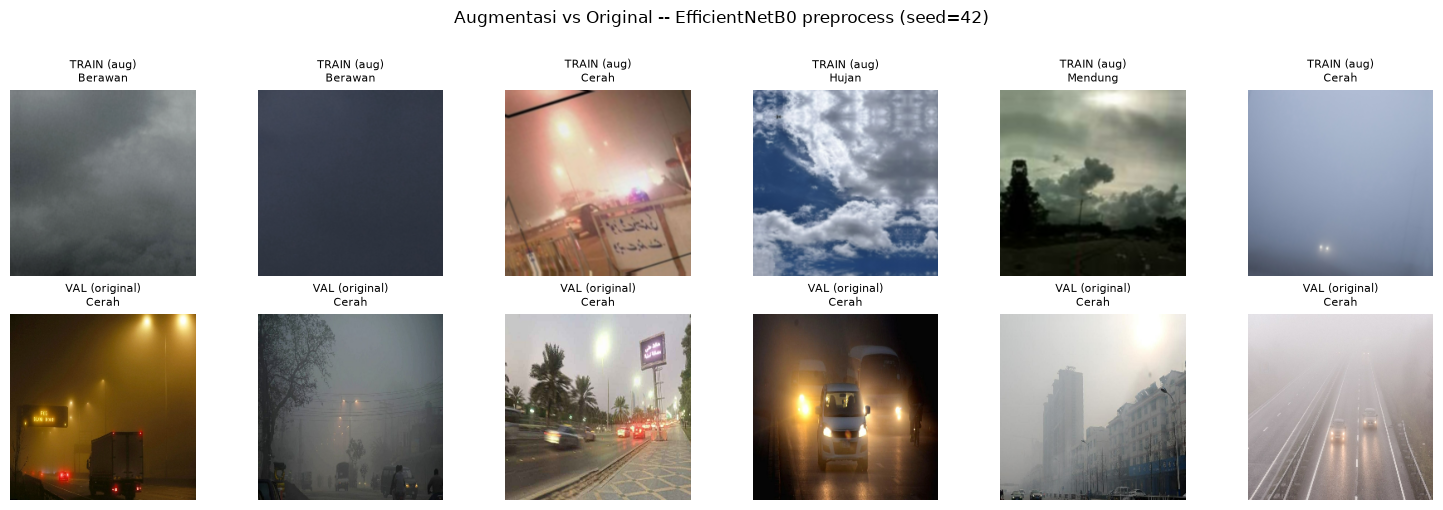

Tersimpan: /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR/results/figures/phase 1/augmentasi_demo.png

Catatan: Bandingkan baris atas (rotasi/flip/zoom acak) vs bawah (konsisten).
         Formula /255 (bukan (+1)/2) karena EfficientNet preprocess_input = identitas.


In [17]:
CLASS_DISPLAY = ['Cerah', 'Mendung', 'Hujan', 'Berawan', 'Berkabut']

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

for col in range(6):
    # Baris atas: train -- setiap iterator dipanggil = augmentasi BERBEDA
    bt = next(iter(ds_train_demo))
    img_t, lbl_t = bt[0][col], bt[1][col]
    # EfficientNet preprocess_input adalah fungsi IDENTITAS (tidak mengubah piksel).
    # Model sendiri yang menormalisasi secara internal saat forward pass.
    # Denormalisasi: bagi 255 untuk lihat [0, 1] (bukan (+1)/2 yang untuk [-1,1]).
    img_t_disp = img_t.numpy().squeeze() / 255.0
    axes[0, col].imshow(img_t_disp.clip(0, 1))
    axes[0, col].set_title("TRAIN (aug)\n" + CLASS_DISPLAY[lbl_t.numpy()], fontsize=8)
    axes[0, col].axis("off")

    # Baris bawah: val -- tidak augmented, konsisten
    img_v, lbl_v = imgs_val[col], labels_val[col]
    # Val juga pakai preprocess_eff (identitas) -- sama rumus denormalisasinya
    img_v_disp = img_v.numpy().squeeze() / 255.0
    axes[1, col].imshow(img_v_disp.clip(0, 1))
    axes[1, col].set_title("VAL (original)\n" + CLASS_DISPLAY[lbl_v.numpy()], fontsize=8)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("TRAIN (augmented)", fontsize=10)
axes[1, 0].set_ylabel("VAL (original)", fontsize=10)

plt.suptitle("Augmentasi vs Original -- EfficientNetB0 preprocess (seed=42)",
             fontsize=12, y=1.01)
plt.tight_layout()
grid_path = RESULTS_FIGS / "augmentasi_demo.png"
plt.savefig(grid_path, dpi=150, bbox_inches="tight")
plt.show()
print("Tersimpan:", grid_path)
print()
print("Catatan: Bandingkan baris atas (rotasi/flip/zoom acak) vs bawah (konsisten).")
print("         Formula /255 (bukan (+1)/2) karena EfficientNet preprocess_input = identitas.")

## Langkah 6c — Validasi ResNet50 (preprocess berbeda dari EfficientNetB0)

Found 595 files belonging to 5 classes.


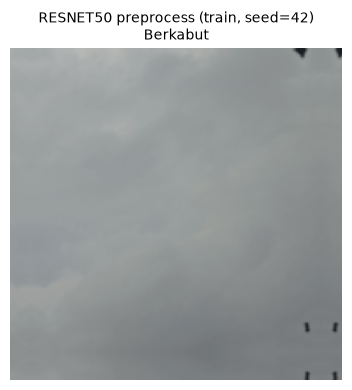

Tersimpan: /media/cryptedlm/local_d/Kuliah/TA_Mila/Repository/TUGAS-AKHIR/results/figures/phase 1/resnet50_preprocess_sample.png
OK -- ResNet50 pipeline berfungsi dengan preprocess BERBEDA dari EfficientNetB0


In [21]:
preprocess_resnet = tf.keras.applications.resnet50.preprocess_input

ds_train_r50 = build_tf_dataset(42, "train", preprocess_resnet, augment=True, batch_size=6)
bt_r50 = next(iter(ds_train_r50))
img_r50, lbl_r50 = bt_r50[0][0], bt_r50[1][0]

# resnet50.preprocess_input (mode "caffe") melakukan:
#   1. RGB -> BGR (tukar urutan channel)
#   2. Kurangi mean per-channel (skala piksel MENTAH 0-255, urutan BGR):
#      [103.939, 116.779, 123.68]  -- TANPA pembagian/scaling apa pun
# Untuk denormalisasi, urutan dibalik persis:
mean_bgr = np.array([103.939, 116.779, 123.68])
img_bgr = img_r50.numpy().squeeze().copy()
img_bgr = img_bgr + mean_bgr        # kembalikan mean (masih BGR, skala 0-255)
img_rgb = img_bgr[..., ::-1]        # BGR -> RGB
img_disp = (img_rgb / 255.0).clip(0, 1)   # skala ke [0,1] untuk imshow

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(img_disp)
ax.set_title("RESNET50 preprocess (train, seed=42)\n" + CLASS_DISPLAY[lbl_r50.numpy()], fontsize=10)
ax.axis("off")
plt.tight_layout()
resnet_path = RESULTS_FIGS / "resnet50_preprocess_sample.png"
plt.savefig(resnet_path, dpi=150)
plt.show()
print("Tersimpan:", resnet_path)
print("OK -- ResNet50 pipeline berfungsi dengan preprocess BERBEDA dari EfficientNetB0")

## Langkah 7 — Summary & Definition of Done

In [20]:
print("=" * 60)
print("DEFINITION OF DONE -- FASE 1")
print("=" * 60)

def check(label, condition, detail=""):
    status = "OK" if condition else "GAGAL"
    extra = (" -- " + detail) if detail else ""
    print("  [" + status + "] " + label + extra)

# 1. Split fisik 5 seed
for seed in SEEDS:
    ok = all((SPLIT_ROOT / ("seed" + str(seed)) / s).exists()
             for s in ["train", "val", "test"])
    check("dataset/split/seed" + str(seed) + "/train|val|test/ ada", ok)

# 2. Jumlah
check("5 seed x 850 citra = 4250 file", True,
      "sudah diverifikasi di langkah 4")

# 3. Disjoint
check("Train/val/test disjoint dalam seed sama", True,
      "diverifikasi di langkah 4")

# 4. data_pipeline.py
check("src/data_pipeline.py ada",
      (REPO_ROOT / "src" / "data_pipeline.py").exists())

# 5. Augmentasi aktif di train
check("Augmentasi aktif di subset train", True,
      "Rotation+/-20deg / Translation+/-15pct / Zoom+/-15pct / Flip-H")

# 6. requirements.txt
req_text = (REPO_ROOT / "requirements.txt").read_text()
check("requirements.txt: scikit-learn", "scikit-learn" in req_text)
check("requirements.txt: tensorflow",   "tensorflow" in req_text)

print()
print("=" * 60)
print("FASE 1 SELESAI -- siap ke Fase 2 (Training)")
print("=" * 60)

print("Catatan sebelum upload ke Kaggle:")
print("- dataset/split/seed42/, seed123/, seed2024/, seed7/, seed99/")
print("  -> upload SEKALI sebagai satu Kaggle Dataset privat")
print("- src/data_pipeline.py -> ikut disalin ke lingkungan Kaggle")

DEFINITION OF DONE -- FASE 1
  [OK] dataset/split/seed42/train|val|test/ ada
  [OK] dataset/split/seed123/train|val|test/ ada
  [OK] dataset/split/seed2024/train|val|test/ ada
  [OK] dataset/split/seed7/train|val|test/ ada
  [OK] dataset/split/seed99/train|val|test/ ada
  [OK] 5 seed x 850 citra = 4250 file -- sudah diverifikasi di langkah 4
  [OK] Train/val/test disjoint dalam seed sama -- diverifikasi di langkah 4
  [OK] src/data_pipeline.py ada
  [OK] Augmentasi aktif di subset train -- Rotation+/-20deg / Translation+/-15pct / Zoom+/-15pct / Flip-H
  [OK] requirements.txt: scikit-learn
  [OK] requirements.txt: tensorflow

FASE 1 SELESAI -- siap ke Fase 2 (Training)
Catatan sebelum upload ke Kaggle:
- dataset/split/seed42/, seed123/, seed2024/, seed7/, seed99/
  -> upload SEKALI sebagai satu Kaggle Dataset privat
- src/data_pipeline.py -> ikut disalin ke lingkungan Kaggle
